In [1]:
print("Hello")

Hello


# Load the dataset

In [1]:
import pandas as pd
df = pd.read_csv("clean_complaint_dataset.csv")
df.head()

,complaint_text,category
0,No power supply in my area since morning. [Ref...,Supply
1,Delay in new connection request. [Ref-1565],EEU Service
2,Received bill for a closed account. [Ref-9001],Billing
3,Received bill for a closed account. [Ref-7828],Billing
4,Rude behavior from EEU employees. [Ref-2989],Employee


# Check for missing data

In [2]:
# check for missing data
df.isnull().sum()

complaint_text    0
category          0
dtype: int64

# Normalize the data

In [3]:
import re
def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r"\[.*?\]", "", text)  # remove [Ref-1234]
    text = re.sub(r"[^a-z\s]", "", text)  # remove punctuation/numbers
    text = re.sub(r"\s+", " ", text).strip()  # remove extra spaces
    return text

# Apply cleaning
df["clean_text"] = df["complaint_text"].apply(clean_text)
df[["complaint_text", "clean_text", "category"]].head()

,complaint_text,clean_text,category
0,No power supply in my area since morning. [Ref...,no power supply in my area since morning,Supply
1,Delay in new connection request. [Ref-1565],delay in new connection request,EEU Service
2,Received bill for a closed account. [Ref-9001],received bill for a closed account,Billing
3,Received bill for a closed account. [Ref-7828],received bill for a closed account,Billing
4,Rude behavior from EEU employees. [Ref-2989],rude behavior from eeu employees,Employee


# Check for duplicates

In [4]:
# Count duplicate rows (across all columns)
duplicate_rows = df.duplicated()
print("Number of duplicate rows:", duplicate_rows.sum())

Number of duplicate rows: 0


In [5]:
df.shape

(280, 3)

In [5]:
df.columns

Index(['complaint_text', 'category', 'clean_text'], dtype='object')

# Tokenization and Vectorization(TF-IDF)

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create the vectorizer
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)

# Fit and transform the clean text
X = vectorizer.fit_transform(df["clean_text"])

# Target variable
y = df["category"]

In [7]:
X.shape, y.shape

((280, 108), (280,))

# Train/Test Split

In [8]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Check the shape
X_train.shape, X_test.shape

((224, 108), (56, 108))

# Model Training

In [9]:
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

# Evaluate the model

In [10]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Make predictions
y_pred = model.predict(X_test)

# Print metrics
print("🔎 Accuracy:", accuracy_score(y_test, y_pred))
print("\n📄 Classification Report:\n", classification_report(y_test, y_pred))

🔎 Accuracy: 1.0

📄 Classification Report:
               precision    recall  f1-score   support

     Billing       1.00      1.00      1.00         8
    Customer       1.00      1.00      1.00         8
 EEU Service       1.00      1.00      1.00         8
    Employee       1.00      1.00      1.00         8
       Meter       1.00      1.00      1.00         8
    Pre-Paid       1.00      1.00      1.00         8
      Supply       1.00      1.00      1.00         8

    accuracy                           1.00        56
   macro avg       1.00      1.00      1.00        56
weighted avg       1.00      1.00      1.00        56



# Random Forest Classifier

In [9]:
# Assuming you already have X_train and y_train
from sklearn.ensemble import RandomForestClassifier
import joblib

# Train the model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Save the model
joblib.dump(model, 'model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')  # Also save the fitted vectorizer


['vectorizer.pkl']

# Cross validation

Cross-Validation Accuracy Scores: [1. 1. 1. 1. 1.]
Mean CV Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

     Billing       1.00      1.00      1.00        40
    Customer       1.00      1.00      1.00        40
 EEU Service       1.00      1.00      1.00        40
    Employee       1.00      1.00      1.00        40
       Meter       1.00      1.00      1.00        40
    Pre-Paid       1.00      1.00      1.00        40
      Supply       1.00      1.00      1.00        40

    accuracy                           1.00       280
   macro avg       1.00      1.00      1.00       280
weighted avg       1.00      1.00      1.00       280



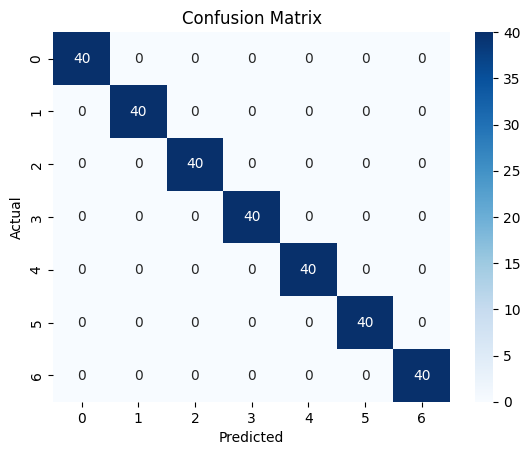

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# Initialize the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 5-Fold Cross-Validation (you can increase to 10)
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy Scores:", scores)
print("Mean CV Accuracy:", scores.mean())

# Optional: Get predicted values for detailed evaluation
y_pred = cross_val_predict(model, X, y, cv=5)
print("\nClassification Report:\n")
print(classification_report(y, y_pred))

# Optional: View confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Save and export the model

In [20]:
import joblib

# Save the model
joblib.dump(model, 'complaint_classifier_model.pkl')

# If you also want to save your vectorizer
joblib.dump(vectorizer, 'vectorizer.pkl')


['vectorizer.pkl']